In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve



In [ ]:
np.random.seed(42)

n = 300

data = pd.DataFrame({
     "age":np.random.randint(18, 65, n),
     "salary":np.random.randint(20000, 100000, n),
     "balance":np.random.randint(0, 200000, n)
})

data["churn"] = (
    (data["balance"] > 100000).astype(int) |
    (data["salary"] < 40000).astype(int)
).astype(int)
data.head()

,age,salary,balance,churn
0,56,58467,186843,1
1,46,43328,188871,1
2,32,23987,144188,1
3,60,78871,156542,1
4,25,42399,173416,1


In [ ]:
print(data.shape)
print(data.info())
print(data.describe())

print(data["churn"].value_counts())

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    40.810000  59643.170000   96728.926667    0.623333
std     13.547164  23136.948358   55867.592002    0.485360
min     18.000000  20301.000000     404.000000    0.000000
25%     29.000000  39680.500000   49034.000000    0.000000
50%     41.500000  59872.000000  101796.500000    1.000000
75%     52.000000  79048.500000  142131.750000    1.000000
max     64.000000  99909.000000  199938.000000    1.000000
churn
1    187
0    113
Name: count, dtype: int64


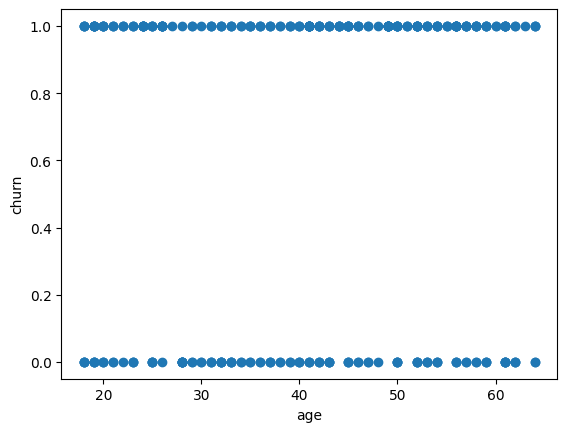

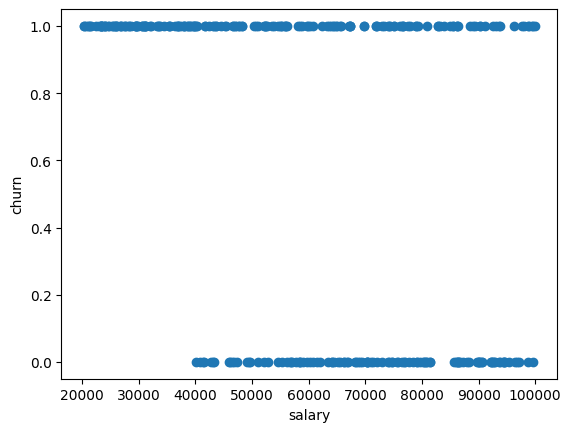

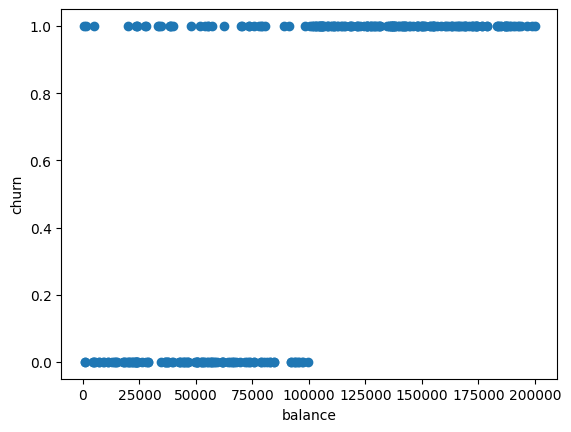

In [ ]:
features = ["age", "salary", "balance"]

for col in features:
    plt.figure()
    plt.scatter(data[col], data["churn"])
    plt.xlabel(col)
    plt.ylabel("churn")
    plt.show()

In [ ]:
X = data[["age", "salary", "balance"]]
y = data["churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred =  model.predict(X_test)
y_prod = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prod))

Accuracy: 0.9
Confusion Matrix:
 [[25  2]
 [ 4 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.94      0.88      0.91        33

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

ROC-AUC: 0.978675645342312


In [ ]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "coefficient":model.coef_[0]
})
print(coeff_df)


   Feature  coefficient
0      age     0.029380
1   salary    -0.000093
2  balance     0.000064


In [ ]:
new_data = pd.DataFrame({
    "age": [35],
    "salary": [30000],
    "balance": [150000]
})

print("Churn Prediction:", model.predict(new_data)[0])
print("Probability:", model.predict_proba(new_data)[0][1])




Churn Prediction: 1
Probability: 0.9995286246808245
